## Phase 1: Library Imports and Data Cleaning
Load the dataset and transform the list of strings into a One-Hot matrix for the Apriori algorithm.

In [13]:
import sys
import subprocess

# Install missing packages if needed
for pkg in ['mlxtend', 'pyECLAT']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing missing package: {pkg}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import pandas as pd
import numpy as np
import ast
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.express as px

# Import all clustering algorithms and helper functions from Clustering.py
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, 
    _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, 
    plot_umap, plot_tsne
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv('customer_info_engineered.csv')

# -----------------------------
# 2. Run cluster analysis
# -----------------------------
df_cluster_analysis = cluster_analysis(df)

print(df_cluster_analysis.head())

# -----------------------------
# 3. Compute silhouette score (ONLY if labels exist)
# -----------------------------
if 'cluster' in df_cluster_analysis.columns:
    sil_score = silhouette_score(df, df_cluster_analysis['cluster'])
    print("Silhouette score:", sil_score)
else:
    print("No cluster labels found in df_cluster_analysis.")


ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.4.

In [15]:
df_basket = pd.read_csv('customer_basket (1).csv')


In [16]:
df_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [17]:


print("Processing lists of products...")
df_basket['list_of_goods'] = df_basket['list_of_goods'].apply(ast.literal_eval)

print("Creating the transaction matrix (One-Hot Encoding)...")
te = TransactionEncoder()
te_ary = te.fit(df_basket['list_of_goods']).transform(df_basket['list_of_goods'])

df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Data ready! {df_transactions.shape[0]} transactions and {df_transactions.shape[1]} unique products.")
display(df_transactions.head(3))

Processing lists of products...
Creating the transaction matrix (One-Hot Encoding)...
Data ready! 100000 transactions and 164 unique products.


,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,...,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Phase 2: Frequent Pattern Extraction (Apriori)
Extract combinations that appear in at least 1% of the transactions. We use low_memory=True to ensure stability with 100,000 rows.

In [24]:
print("Running the Apriori algorithm...")
frequent_itemsets = apriori(df_transactions, min_support=0.02, use_colnames=True, low_memory=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets.")
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

Running the Apriori algorithm...
Found 171 frequent itemsets.


,support,itemsets
3,0.12811,(asparagus)
0,0.12145,(airpods)
26,0.09952,(cereals)
56,0.09934,(fresh bread)
18,0.09654,(butter)
45,0.09241,(eggs)
120,0.08695,(protein bar)
36,0.08623,(cooking oil)
146,0.08395,(toilet paper)
5,0.08318,(babies food)


## Phase 3: Generation of Association Rules
Discover rules with a Lift greater than 1.0 (which indicates a true positive association between the products).

In [25]:
print("Generating association rules...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"Generated {len(rules)} rules with Lift >= 1.0")
display(rules.sort_values('lift', ascending=False).head(10))

Generating association rules...
Generated 14 rules with Lift >= 1.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(airpods),(bluetooth headphones),0.12145,0.07279,0.02485,0.204611,2.810976,1.0,0.016010,1.165731,0.733312,0.146703,0.142169,0.273002
1,(bluetooth headphones),(airpods),0.07279,0.12145,0.02485,0.341393,2.810976,1.0,0.016010,1.333952,0.694828,0.146703,0.250348,0.273002
2,(airpods),(energy drink),0.12145,0.07525,0.02525,0.207904,2.762850,1.0,0.016111,1.167473,0.726259,0.147273,0.143449,0.271726
3,(energy drink),(airpods),0.07525,0.12145,0.02525,0.335548,2.762850,1.0,0.016111,1.322218,0.689976,0.147273,0.243695,0.271726
10,(cereals),(eggs),0.09952,0.09241,0.02180,0.219051,2.370430,1.0,0.012603,1.162164,0.642031,0.128137,0.139536,0.227478
11,(eggs),(cereals),0.09241,0.09952,0.02180,0.235905,2.370430,1.0,0.012603,1.178493,0.637001,0.128137,0.151458,0.227478
12,(cereals),(fresh bread),0.09952,0.09934,0.02249,0.225985,2.274861,1.0,0.012604,1.163620,0.622349,0.127516,0.140613,0.226189
13,(fresh bread),(cereals),0.09934,0.09952,0.02249,0.226394,2.274861,1.0,0.012604,1.164004,0.622225,0.127516,0.140896,0.226189
6,(eggs),(butter),0.09241,0.09654,0.02015,0.218050,2.258649,1.0,0.011229,1.155394,0.613997,0.119372,0.134494,0.213386
7,(butter),(eggs),0.09654,0.09241,0.02015,0.208722,2.258649,1.0,0.011229,1.146992,0.616804,0.119372,0.128155,0.213386


## Phase 4: Visualization and Insights
Scatter plot of Support vs Confidence to visualize the impact of Lift.

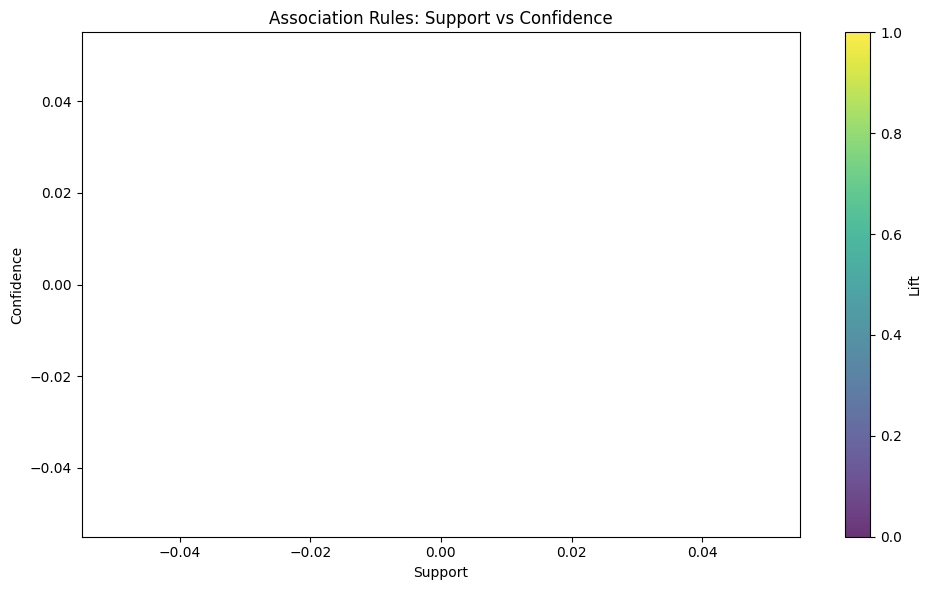

In [30]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.tight_layout()
plt.show()

## Phase 5: Cross-cluster Basket Analysis
Integrate cluster labels from `dataset_clusters.csv` with the `customer_basket` transactions using `customer_info.csv` as a bridge. Then analyze product frequencies and association rules per cluster.

In [28]:
import sys
import subprocess
import ast
import pandas as pd
import numpy as np

# 1. Garantir que as bibliotecas necessárias estão instaladas e importadas
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    print("Instalando mlxtend...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules

print('Loading cluster labels and customer mapping...')

# NOTA: Certifica-te de que o 'df_basket' já foi carregado anteriormente no teu notebook.
# Se precisares de o carregar de um ficheiro, descomenta a linha abaixo:
# df_basket = pd.read_csv('o_teu_ficheiro_de_baskets.csv')

df_clusters = pd.read_csv('dataset_clusters.csv')
df_customers = pd.read_csv('customer_info.csv')

# 2. Validar se a coluna 'customer_name' existe em df_clusters
if 'customer_name' not in df_clusters.columns:
    raise ValueError('dataset_clusters.csv must contain customer_name')

# 3. Descobrir dinamicamente se a coluna se chama 'Cluster' ou 'cluster' (Evita o KeyError)
cluster_col_found = None
for col in ['Cluster', 'cluster']:
    if col in df_clusters.columns:
        cluster_col_found = col
        break

if cluster_col_found is None:
    raise ValueError('dataset_clusters.csv must contain either "Cluster" or "cluster"')

# 4. Filtrar e uniformizar o DataFrame de clusters para 'Cluster'
df_clusters = df_clusters[['customer_name', cluster_col_found]]
df_clusters = df_clusters.rename(columns={cluster_col_found: 'Cluster'})

# 5. Filtrar as colunas necessárias de clientes e fazer os merges
df_customers = df_customers[['customer_id', 'customer_name']]

df_basket_clusters = df_basket.merge(df_customers, on='customer_id', how='left')
df_basket_clusters = df_basket_clusters.merge(df_clusters, on='customer_name', how='left')

print('Merged baskets with customer info and cluster labels:')
print('  transactions:', len(df_basket_clusters))
print('  missing customer_name:', df_basket_clusters['customer_name'].isna().sum())
print('  missing cluster labels:', df_basket_clusters['Cluster'].isna().sum())
display(df_basket_clusters.head())

# 6. Explorar a cobertura de cestas (baskets) por cluster (incluindo NaN se existirem)
cluster_coverage = (
    df_basket_clusters.groupby('Cluster', dropna=False)
    .agg(transactions=('invoice_id', 'nunique'),
         customers=('customer_id', 'nunique'))
    .reset_index()
    .sort_values('transactions', ascending=False)
)
print('Customer basket coverage by cluster:')
display(cluster_coverage)

# 7. Função auxiliar para garantir que 'list_of_goods' é tratado como uma lista real
def parse_basket(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            # Caso a string use delimitadores normais separados por vírgula
            return [x.strip() for x in val.replace('[','').replace(']','').replace("'",'').split(',')]
    return []

# Aplicar a conversão de forma segura
df_basket_clusters['list_of_goods_parsed'] = df_basket_clusters['list_of_goods'].apply(parse_basket)

# 8. Explodir produtos para análise de frequência por cluster
print('Computing top products per cluster...')
records = []
for _, row in df_basket_clusters[df_basket_clusters['Cluster'].notna()].iterrows():
    for prod in row['list_of_goods_parsed']:
        if prod:  # Ignorar strings vazias
            records.append({'Cluster': row['Cluster'], 'product': prod})

if records:
    df_products = pd.DataFrame(records)
    top_products_by_cluster = (
        df_products.groupby(['Cluster', 'product'])
        .size()
        .reset_index(name='count')
        .sort_values(['Cluster', 'count'], ascending=[True, False])
    )

    for cluster_label, group in top_products_by_cluster.groupby('Cluster'):
        print(f'\n--- Cluster {cluster_label} top products ---')
        display(group.head(10))
else:
    print('No cluster-labeled basket records found to analyze.')

# 9. Gerar regras de associação específicas para cada cluster
print('\nGenerating cluster-specific association rules...')
for cluster_label in sorted(df_basket_clusters['Cluster'].dropna().unique()):
    df_cluster = df_basket_clusters[df_basket_clusters['Cluster'] == cluster_label]
    
    if len(df_cluster) < 20:
        print(f'  Skipping cluster {cluster_label} because it has only {len(df_cluster)} baskets.')
        continue

    # Criar a matriz binária One-Hot necessária para o Apriori baseado no TransactionEncoder
    te_cluster = TransactionEncoder()
    te_ary_cluster = te_cluster.fit(df_cluster['list_of_goods_parsed']).transform(df_cluster['list_of_goods_parsed'])
    cluster_transactions = pd.DataFrame(te_ary_cluster, columns=te_cluster.columns_)

    # Aplicar o algoritmo Apriori para encontrar conjuntos frequentes
    frequent_cluster = apriori(cluster_transactions, min_support=0.02, use_colnames=True, low_memory=True)
    if frequent_cluster.empty:
        print(f'  No frequent itemsets found for cluster {cluster_label}.')
        continue

    # Extrair as regras de associação
    rules_cluster = association_rules(frequent_cluster, metric='lift', min_threshold=1.0)
    if rules_cluster.empty:
        print(f'  No association rules found for cluster {cluster_label}.')
        continue

    print(f'\n--- Cluster {cluster_label} top rules ---')
    display(rules_cluster.sort_values('lift', ascending=False).head(10))

Loading cluster labels and customer mapping...
Merged baskets with customer info and cluster labels:
  transactions: 103349
  missing customer_name: 0
  missing cluster labels: 0


,invoice_id,list_of_goods,customer_id,customer_name,Cluster
0,3700630,"[chicken, rice, pepper, whole wheat rice, shri...",12912,Msc. George Davis,2
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, ...",22853,Patricia Silva,0
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy...",19,Phd. Evelyn Quinn,2
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,Msc. David Stupar,0
4,7165061,"[rice, frozen smoothie, black tea, tea, minecr...",27807,Noel Froelich,0


Customer basket coverage by cluster:


,Cluster,transactions,customers
0,0,48757,15078
4,4,18797,3580
2,2,13669,4272
3,3,12189,2997
1,1,8729,2805


Computing top products per cluster...

--- Cluster 0 top products ---


...


--- Cluster 2 top rules ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
19,(bluetooth headphones),(energy drink),0.082139,0.085340,0.020589,0.250664,2.937239,1.0,0.013580,1.220628,0.718566,0.140168,0.180749,0.245963
18,(energy drink),(bluetooth headphones),0.085340,0.082139,0.020589,0.241262,2.937239,1.0,0.013580,1.209720,0.721081,0.140168,0.173363,0.245963
0,(airpods),(bluetooth headphones),0.150673,0.082139,0.032521,0.215838,2.627715,1.0,0.020145,1.170499,0.729332,0.162368,0.145663,0.305882
1,(bluetooth headphones),(airpods),0.082139,0.150673,0.032521,0.395926,2.627715,1.0,0.020145,1.405997,0.674875,0.162368,0.288761,0.305882
5,(energy drink),(airpods),0.085340,0.150673,0.031357,0.367434,2.438619,1.0,0.018498,1.342669,0.644974,0.153217,0.255215,0.287773
4,(airpods),(energy drink),0.150673,0.085340,0.031357,0.208112,2.438619,1.0,0.018498,1.155037,0.694587,0.153217,0.134227,0.287773
13,(salad),(asparagus),0.066133,0.139614,0.021317,0.322332,2.308732,1.0,0.012084,1.269627,0.607005,0.115582,0.212367,0.237508
12,(asparagus),(salad),0.139614,0.066133,0.021317,0.152684,2.308732,1.0,0.012084,1.102147,0.658846,0.115582,0.092680,0.237508
11,(carrots),(asparagus),0.073190,0.139614,0.021535,0.294235,2.107480,1.0,0.011317,1.219082,0.566998,0.112590,0.179710,0.224241
10,(asparagus),(carrots),0.139614,0.073190,0.021535,0.154247,2.107480,1.0,0.011317,1.095840,0.610772,0.112590,0.087458,0.224241



--- Cluster 3 top rules ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
216,"(dog food, cooking oil)",(napkins),0.080558,0.243970,0.030845,0.382892,1.569420,1.0,0.011191,1.225117,0.394611,0.105028,0.183752,0.254661
221,(napkins),"(dog food, cooking oil)",0.243970,0.080558,0.030845,0.126429,1.569420,1.0,0.011191,1.052510,0.479904,0.105028,0.049890,0.254661
220,(cooking oil),"(dog food, napkins)",0.238720,0.085480,0.030845,0.129210,1.511579,1.0,0.010439,1.050218,0.444567,0.105145,0.047817,0.245027
217,"(dog food, napkins)",(cooking oil),0.085480,0.238720,0.030845,0.360845,1.511579,1.0,0.010439,1.191071,0.370074,0.105145,0.160420,0.245027
219,(dog food),"(cooking oil, napkins)",0.255291,0.080804,0.030845,0.120823,1.495257,1.0,0.010216,1.045518,0.444762,0.101048,0.043537,0.251274
218,"(cooking oil, napkins)",(dog food),0.080804,0.255291,0.030845,0.381726,1.495257,1.0,0.010216,1.204496,0.360335,0.101048,0.169777,0.251274
205,"(napkins, babies food)",(cooking oil),0.081788,0.238720,0.028958,0.354062,1.483168,1.0,0.009434,1.178565,0.354785,0.099325,0.151511,0.237684
208,(cooking oil),"(napkins, babies food)",0.238720,0.081788,0.028958,0.121306,1.483168,1.0,0.009434,1.044973,0.427921,0.099325,0.043037,0.237684
198,"(dog food, cooking oil)",(babies food),0.080558,0.245201,0.029286,0.363544,1.482636,1.0,0.009533,1.185940,0.354047,0.098783,0.156787,0.241491
203,(babies food),"(dog food, cooking oil)",0.245201,0.080558,0.029286,0.119438,1.482636,1.0,0.009533,1.044154,0.431275,0.098783,0.042287,0.241491


  No association rules found for cluster 4.


In [29]:
import pandas as pd

# Filtrar os dados apenas para o Cluster 4
df_c4 = df_basket_clusters[df_basket_clusters['Cluster'] == 4]

print(f"=== DIAGNÓSTICO DO CLUSTER 4 ===")
print(f"1. Número total de transações no Cluster 4: {len(df_c4)}")

if len(df_c4) == 0:
    print("   -> ERRO: O Cluster 4 está completamente vazio! Verifica se os nomes dos clientes batem certo.")
else:
    # 2. Testar o TransactionEncoder e Apriori
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
    
    te = TransactionEncoder()
    te_ary = te.fit(df_c4['list_of_goods_parsed']).transform(df_c4['list_of_goods_parsed'])
    df_trans_c4 = pd.DataFrame(te_ary, columns=te.columns_)
    
    # Calcular a frequência absoluta de cada produto para ver se são raros
    print(f"\n2. Frequência dos produtos mais comuns no Cluster 4:")
    print(df_trans_c4.sum().sort_values(ascending=False).head(10))
    
    # Tentar correr o apriori
    min_sup_teste = 0.02
    freq_items = apriori(df_trans_c4, min_support=min_sup_teste, use_colnames=True)
    
    print(f"\n3. Teste do Apriori (min_support={min_sup_teste}):")
    print(f"   -> Foram encontrados {len(freq_items)} itemsets frequentes.")
    
    if freq_items.empty:
        print("   -> CONCLUSÃO: O suporte de 2% é demasiado alto. As pessoas neste cluster compram produtos muito variados.")
        # Teste extra com suporte mais baixo
        freq_items_baixo = apriori(df_trans_c4, min_support=0.005, use_colnames=True)
        print(f"      Se baixares o min_support para 0.5% (0.005), encontras {len(freq_items_baixo)} itemsets.")
    else:
        # Se encontrou itemsets mas falhou nas regras
        print(f"\n4. Teste das Regras de Associação:")
        rules = association_rules(freq_items, metric='lift', min_threshold=0.0) # threshold 0 para ver tudo
        print(f"   -> Foram geradas {len(rules)} regras no total (sem filtro de Lift).")
        
        if not rules.empty:
            print(f"   -> O Lift máximo encontrado foi: {rules['lift'].max():.2f}")
            if rules['lift'].max() < 1.0:
                print("   -> CONCLUSÃO: As regras existem, mas o 'lift' é inferior a 1.0. Isto significa que as compras dos produtos são estatisticamente independentes (comprar A não influencia comprar B).")

=== DIAGNÓSTICO DO CLUSTER 4 ===
1. Número total de transações no Cluster 4: 18892

2. Frequência dos produtos mais comuns no Cluster 4:
airpods         1895
dog food        1845
asparagus       1807
cat food        1673
protein bar     1673
babies food     1643
french fries    1577
chicken         1560
toilet paper    1487
red wine        1477
dtype: int64

3. Teste do Apriori (min_support=0.02):
   -> Foram encontrados 164 itemsets frequentes.

4. Teste das Regras de Associação:
   -> Foram geradas 0 regras no total (sem filtro de Lift).
